# 4.9 多空股票市场中性策略 (Long-Short Equity)

## 学习目标
- 理解多空策略的两种类型：美元中性 vs Beta 中性
- 给定因子得分，用治度分尺将股票画分为多头/空头并分配权重
- 评估策略的多/空两端分别贡献的 Alpha


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)
n_stocks = 100
factor_scores = np.random.normal(0, 1, n_stocks)
fwd_returns = 0.05 * factor_scores + np.random.normal(0, 2, n_stocks)
df = pd.DataFrame({'factor_score': factor_scores, 'fwd_return': fwd_returns})
print(f'模拟股票池：{n_stocks} 只，IC={np.corrcoef(factor_scores, fwd_returns)[0,1]:.4f}')


模拟股票池：100 只，IC=-0.1130


In [2]:
import matplotlib.pyplot as plt

# 1. 设置系统自带的中文字体（这里使用黑体 SimHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 如果你想用微软雅黑，可以改成 ['Microsoft YaHei']

# 2. 解决更换字体后，负号（-）显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

## 1. 分位数赋权与多空两端收益


多头 Q5 平均收益: 0.4805
空头 Q1 平均收益: 0.9463
多空策略总收益 (Q5-Q1): -0.4658
权重加权策略实际收益: -0.4658


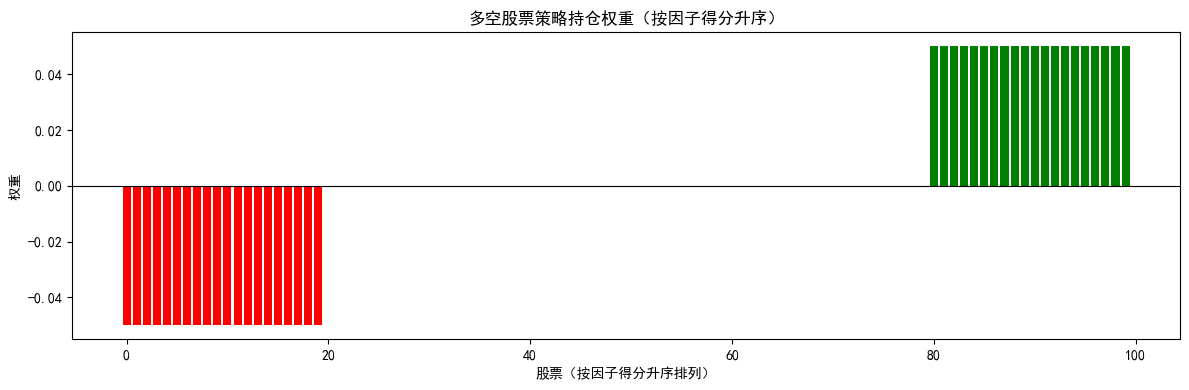

In [3]:
df['quintile'] = pd.qcut(df['factor_score'], q=5, labels=['Q1','Q2','Q3','Q4','Q5'])
df['weight'] = 0.0
df.loc[df['quintile']=='Q5', 'weight'] = 1.0/20
df.loc[df['quintile']=='Q1', 'weight'] = -1.0/20

long_ret  = df[df['weight'] > 0]['fwd_return'].mean()
short_ret = df[df['weight'] < 0]['fwd_return'].mean()
strat_ret = (df['weight'] * df['fwd_return']).sum()

print(f'多头 Q5 平均收益: {long_ret:.4f}')
print(f'空头 Q1 平均收益: {short_ret:.4f}')
print(f'多空策略总收益 (Q5-Q1): {long_ret - short_ret:.4f}')
print(f'权重加权策略实际收益: {strat_ret:.4f}')

# 可视化
colors = ['green' if w>0 else ('red' if w<0 else 'lightgray') for w in df.sort_values('factor_score')['weight']]
plt.figure(figsize=(12, 4))
plt.bar(range(n_stocks), df.sort_values('factor_score')['weight'], color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('多空股票策略持仓权重（按因子得分升序）')
plt.xlabel('股票（按因子得分升序排列）')
plt.ylabel('权重')
plt.tight_layout()
plt.show()


## 2. 美元中性 vs Beta 中性

| 类型 | 目标 | 优点 | 缺点 |
|--|--|--|--|
| **美元中性** | 多头金额 = 空头金额 | 简单 | 可能有 Beta 暴露 |
| **Beta 中性** | 组合 Beta = 0 | 完全对冲市场 | 需动态调整 |


In [4]:
dollar_long  = df[df['weight']>0]['weight'].sum()
dollar_short = df[df['weight']<0]['weight'].sum()
print(f'多头权重合计: {dollar_long:+.4f}')
print(f'空头权重合计: {dollar_short:+.4f}')
print(f'净权重（应趋近0）: {dollar_long+dollar_short:+.6f}')

beta_long = 1.2   # 假设多头平均 Beta
beta_short = 0.7  # 假设空头平均 Beta
portfolio_beta = dollar_long * beta_long + dollar_short * beta_short
print(f'\n组合 Beta（非 Beta 中性）: {portfolio_beta:.4f}')
print('处理方法：额外做空股指期货以中和剩余 Beta')


多头权重合计: +1.0000
空头权重合计: -1.0000
净权重（应趋近0）: +0.000000

组合 Beta（非 Beta 中性）: 0.5000
处理方法：额外做空股指期货以中和剩余 Beta


## 🎯 练习

1. 将因子得分层数改为 3 分位（T3 vs B3）和 10 分位（D10 vs D1），对比哪种分位方式的 IC 和策略夏普更高。
2. 实现一个动态 Beta 识别继续训练，如果当前组合 Beta > 0.1，自动调整空头权重使 Beta 放回 0。
3. 在同样的因子得分下，分别计算价格加权和市值加权两种权重方式对策略 Sharpe 比率的影响。

---
**下一节** → `07_kalman_filter_applications.ipynb`
